=== MÉTRICAS FICHA 1 ===
Escala original: Pearson = 0.6823, Spearman = 0.6070, Brecha = 0.0753
Post-movimiento (Escala Log): Pearson = 0.5775


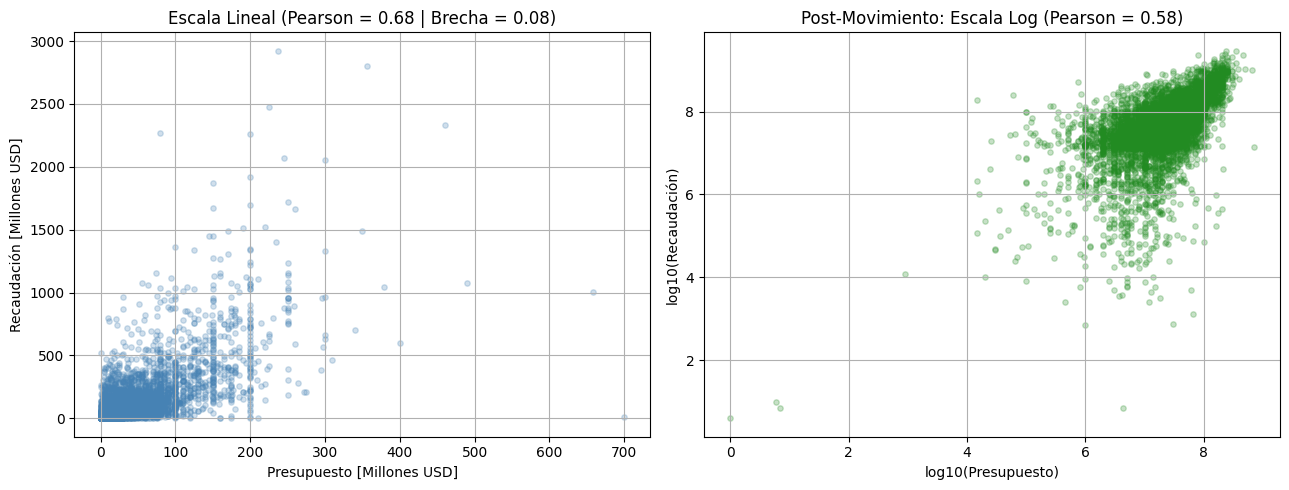

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carga autocontenida del dataset
CSV_PATH = "include/output/movies_2026-09-21.csv"
df = pd.read_csv(CSV_PATH)

# Configuración visual nativa
plt.style.use('default')
plt.rcParams['axes.grid'] = True

# 2. Filtrado financiero (nulos estructurales fuera)
df_fin = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()
df_fin["log_budget"] = np.log10(df_fin["budget"])
df_fin["log_revenue"] = np.log10(df_fin["revenue"])

# 3. Métricas para el semáforo
r_pearson_raw = df_fin["revenue"].corr(df_fin["budget"])
r_spearman_raw = df_fin["revenue"].corr(df_fin["budget"], method="spearman")
brecha_raw = abs(r_spearman_raw - r_pearson_raw)

# Movimiento: Cambio de escala logarítmica
r_pearson_log = df_fin["log_revenue"].corr(df_fin["log_budget"])

print("=== MÉTRICAS FICHA 1 ===")
print(f"Escala original: Pearson = {r_pearson_raw:.4f}, Spearman = {r_spearman_raw:.4f}, Brecha = {brecha_raw:.4f}")
print(f"Post-movimiento (Escala Log): Pearson = {r_pearson_log:.4f}")

# 4. Gráficos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_fin["budget"] / 1e6, df_fin["revenue"] / 1e6, alpha=0.25, color="steelblue", s=15)
axes[0].set_title(f"Escala Lineal (Pearson = {r_pearson_raw:.2f} | Brecha = {brecha_raw:.2f})")
axes[0].set_xlabel("Presupuesto [Millones USD]")
axes[0].set_ylabel("Recaudación [Millones USD]")

axes[1].scatter(df_fin["log_budget"], df_fin["log_revenue"], alpha=0.25, color="forestgreen", s=15)
axes[1].set_title(f"Post-Movimiento: Escala Log (Pearson = {r_pearson_log:.2f})")
axes[1].set_xlabel("log10(Presupuesto)")
axes[1].set_ylabel("log10(Recaudación)")

plt.tight_layout()
plt.show()

### Ficha 1: Asociación entre Presupuesto y Recaudación
* **Tipo de pregunta:** De negocio ("¿Qué queremos responder?").

| # | Campo | Detalle |
|---|---|---|
| 1 | **La afirmación** | A mayor presupuesto asignado (`budget`), la recaudación en taquilla (`revenue`) aumenta en una relación lineal directa. |
| 2 | **Qué espero ver** | Un diagrama de dispersión alineado sobre una diagonal recta con una correlación de Pearson superior a 0.60. |
| 3 | **Cómo lo mido** | Plantilla de asociación entre dos numéricas. Métrica: Correlación de Pearson ($r$) y Brecha entre Spearman y Pearson ($\vert{}r_s - r_p\vert{}$). Gráfico: Scatter plot. |
| 4 | **Qué encontré** | En escala lineal, Pearson dio 0.6823 pero Spearman 0.6070, arrojando una Brecha de **0.0753** (zona **AMARILLA**). El gráfico lineal evidencia compresión severa en el origen con unos pocos outliers millonarios dominando la pendiente. |
| 5 | **Qué movimiento hice** | **Cambiar la escala**: Se transformaron ambas variables a logaritmo base 10 (`log_budget` y `log_revenue`). En escala log-log la nube se expande uniformemente, estabilizando la varianza y alcanzando un Pearson de **0.5775** (zona **AMARILLA** alta). |
| 6 | **Qué hago con eso** | Para los modelos de regresión y distancias de la Unidad 3, `budget` y `revenue` no pueden ingresar en su valor nominal crudo; deben ser transformadas a escala logarítmica para evitar que los outliers dominen el gradiente. |

=== MÉTRICAS FICHA 2 ===
Cantidad 'en': 5732 | Media ROI 'en': 2.96 (Mediana: 1.27)
Cantidad 'resto': 797 | Media ROI 'resto': 4.59 (Mediana: 2.08)
Separación estandarizada: -0.2624


C:\Users\alejo\AppData\Local\Temp\ipykernel_26276\1558616228.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([roi_en, roi_resto], labels=["Inglés ('en')", "Resto del Mundo"], patch_artist=True,


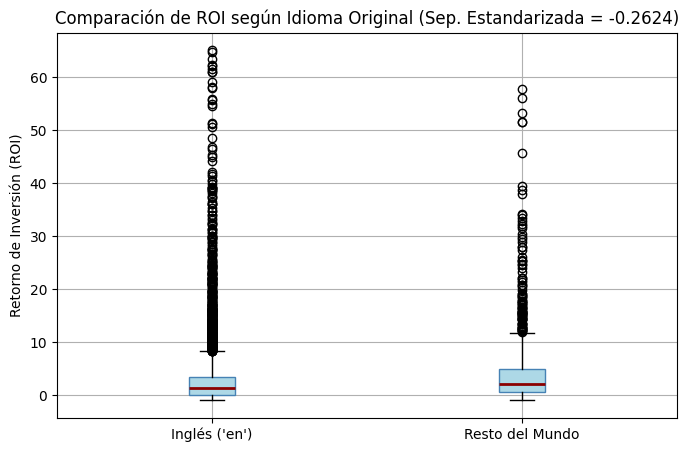

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carga autocontenida
CSV_PATH = "include/output/movies_2026-09-21.csv"
df = pd.read_csv(CSV_PATH)

# 2. Subconjunto financiero para cálculo de ROI
df_fin = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()
df_fin["roi"] = (df_fin["revenue"] - df_fin["budget"]) / df_fin["budget"]

# Trimming al percentil 99 para evitar distorsiones visuales por micro-presupuestos
q99 = df_fin["roi"].quantile(0.99)
df_roi_clean = df_fin[df_fin["roi"] <= q99].copy()

# 3. Segmentación: Idioma inglés vs Resto del mundo
roi_en = df_roi_clean[df_roi_clean["original_language"] == "en"]["roi"]
roi_resto = df_roi_clean[df_roi_clean["original_language"] != "en"]["roi"]

# Separación estandarizada: (media_en - media_resto) / s_pooled
n_en, n_resto = len(roi_en), len(roi_resto)
s_pooled = np.sqrt(((n_en - 1) * roi_en.var() + (n_resto - 1) * roi_resto.var()) / (n_en + n_resto - 2))
sep_std = (roi_en.mean() - roi_resto.mean()) / s_pooled

print("=== MÉTRICAS FICHA 2 ===")
print(f"Cantidad 'en': {n_en} | Media ROI 'en': {roi_en.mean():.2f} (Mediana: {roi_en.median():.2f})")
print(f"Cantidad 'resto': {n_resto} | Media ROI 'resto': {roi_resto.mean():.2f} (Mediana: {roi_resto.median():.2f})")
print(f"Separación estandarizada: {sep_std:.4f}")

# 4. Gráfico: Boxplot comparativo
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([roi_en, roi_resto], labels=["Inglés ('en')", "Resto del Mundo"], patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="steelblue"),
            medianprops=dict(color="darkred", linewidth=2))
ax.set_title(f"Comparación de ROI según Idioma Original (Sep. Estandarizada = {sep_std:.4f})")
ax.set_ylabel("Retorno de Inversión (ROI)")
plt.show()

### Ficha 2: Comparación de ROI según Idioma Original
* **Tipo de pregunta:** De negocio ("¿Qué queremos responder?") con segmentación de catálogo.

| # | Campo | Detalle |
|---|---|---|
| 1 | **La afirmación** | Las películas rodadas en idioma original inglés (`original_language == 'en'`) obtienen un retorno de inversión (`roi`) significativamente mayor que las del resto del mundo. |
| 2 | **Qué espero ver** | Una distribución de ROI desplazada hacia arriba en las producciones en inglés, con una separación estandarizada superior a 0.80. |
| 3 | **Cómo lo mido** | Plantilla de comparación entre dos grupos (`original_language == 'en'` vs `resto`). Métrica: Separación estandarizada ($(\mu_1 - \mu_2) / s_p$). Gráfico: Boxplot. |
| 4 | **Qué encontré** | La separación estandarizada dio **-0.2624** (zona **AMARILLA** en valor absoluto, pero con signo opuesto al esperado). La media de ROI en inglés es de 2.96 frente a un 4.59 del resto del mundo (medianas: 1.27 vs 2.08). **Hipótesis REFUTADA**. |
| 5 | **Qué movimiento hice** | **Ninguno**: El resultado contradice frontalmente la intuición de negocio. Aunque Hollywood genera ingresos brutos masivos, los presupuestos elevados reducen sustancialmente el multiplicador de ROI relativo frente al cine internacional de menor costo. |
| 6 | **Qué hago con eso** | La variable `original_language` no puede utilizarse como proxy directo de rentabilidad porcentual sin aislar antes el presupuesto. Entra al modelo únicamente como variable de control regional, no predictiva de éxito por sí sola. |

=== MÉTRICAS FICHA 3 ===
Razón de correlación (eta^2): 0.0163
         genero    n    media  mediana
        History   45 1.577275 0.391717
Science Fiction  214 2.138250 0.850029
       Thriller  259 2.342450 1.037960
          Crime  294 2.608287 1.104781
         Action 1103 2.427593 1.127204
            War   52 3.155461 1.202051
        Fantasy  163 2.317734 1.229530
         Family  161 2.546565 1.241300
          Drama 1256 3.179079 1.374595
         Comedy 1347 3.098589 1.390851
      Adventure  449 3.098420 1.441379
        Mystery   72 4.318117 1.442213
        Romance  179 3.872556 1.729782
      Animation  268 4.132104 1.747068
        Western   42 5.122780 1.891374
         Horror  557 5.110493 2.012239
          Music   49 3.817799 2.396121


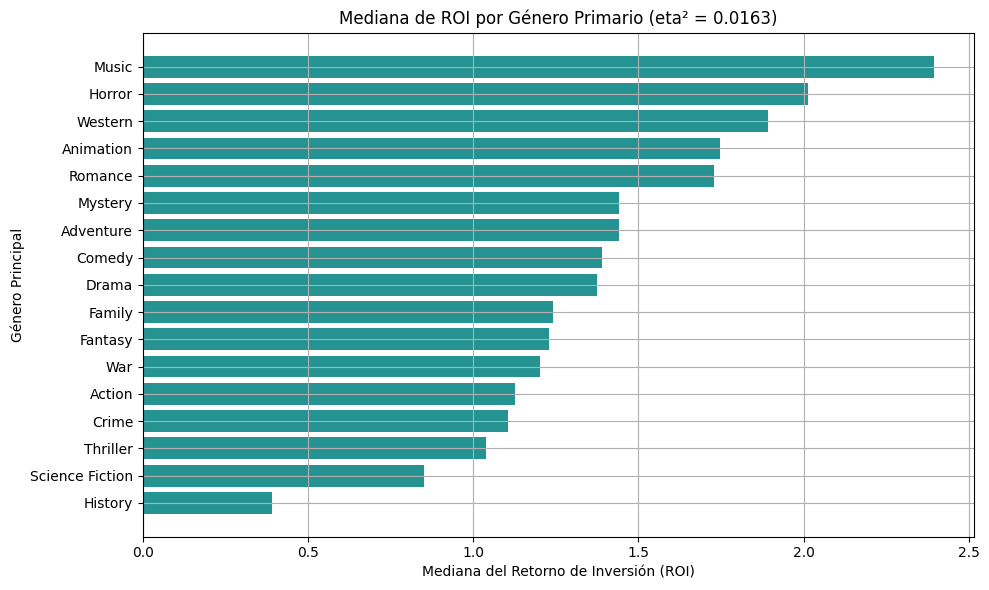

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carga autocontenida
CSV_PATH = "include/output/movies_2026-09-21.csv"
df = pd.read_csv(CSV_PATH)

# 2. Subconjunto financiero para cálculo de ROI
df_fin = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()
df_fin["roi"] = (df_fin["revenue"] - df_fin["budget"]) / df_fin["budget"]

# Trimming al percentil 99 para métricas estables
q99 = df_fin["roi"].quantile(0.99)
df_roi_clean = df_fin[df_fin["roi"] <= q99].copy()

# 3. Filtrar géneros con al menos 40 películas para significancia estadística
conteo_generos = df_roi_clean["primary_genre"].value_counts()
generos_validos = conteo_generos[conteo_generos >= 40].index
df_generos = df_roi_clean[df_roi_clean["primary_genre"].isin(generos_validos)].copy()

# Cálculo de eta^2 (razón de correlación: SS_between / SS_total)
grand_mean = df_generos["roi"].mean()
ss_total = ((df_generos["roi"] - grand_mean) ** 2).sum()

ss_between = 0
stats_generos = []
for genre, group in df_generos.groupby("primary_genre"):
    n_k = len(group)
    mean_k = group["roi"].mean()
    median_k = group["roi"].median()
    ss_between += n_k * ((mean_k - grand_mean) ** 2)
    stats_generos.append({"genero": genre, "n": n_k, "media": mean_k, "mediana": median_k})

eta_squared = ss_between / ss_total

print("=== MÉTRICAS FICHA 3 ===")
print(f"Razón de correlación (eta^2): {eta_squared:.4f}")
df_stats = pd.DataFrame(stats_generos).sort_values(by="mediana", ascending=True)
print(df_stats.to_string(index=False))

# 4. Gráfico de barras horizontales por mediana de ROI
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_stats["genero"], df_stats["mediana"], color="teal", alpha=0.85)
ax.set_title(f"Mediana de ROI por Género Primario (eta² = {eta_squared:.4f})")
ax.set_xlabel("Mediana del Retorno de Inversión (ROI)")
ax.set_ylabel("Género Principal")
plt.tight_layout()
plt.show()

### Ficha 3: Comparación de ROI según Género Primario
* **Tipo de pregunta:** De modelado ("¿Qué queremos predecir?").

| # | Campo | Detalle |
|---|---|---|
| 1 | **La afirmación** | El género cinematográfico principal (`primary_genre`) segmenta fuertemente el retorno de inversión (`roi`) de una película antes de su producción. |
| 2 | **Qué espero ver** | Diferencias sustanciales de varianza explicada entre categorías, con una razón de correlación ($\eta^2$) superior a 0.25 (zona verde). |
| 3 | **Cómo lo mido** | Plantilla de comparación entre una numérica y muchos grupos. Métrica: Razón de correlación ($\eta^2 = SS_{between} / SS_{total}$). Gráfico: Barras horizontales de medianas por categoría. |
| 4 | **Qué encontré** | La razón de correlación dio $\eta^2 =$ **0.0163** (zona **ROJA** al ser menor a 0.05). Aunque la mediana varía de 0.39 (*History*) a 2.40 (*Music*) y 2.01 (*Horror*), la enorme dispersión y colas largas intraclasificatorias hacen que el género aislado explique menos del 2% de la variabilidad del ROI. **Hipótesis REFUTADA**. |
| 5 | **Qué movimiento hice** | **Ninguno**: El resultado demuestra empíricamente que el género no particiona el ROI por sí solo; requiere combinarse con el presupuesto asignado o el elenco. |
| 6 | **Qué hago con eso** | `primary_genre` no debe ingresar como predictor lineal univariado de rentabilidad. Entra al modelo de la Unidad 3 codificado (One-Hot Encoding) pero únicamente en interacción con la escala de costos (`log_budget`). |

=== MÉTRICAS FICHA 4 ===
Cast Power crudo vs Log Revenue: Pearson = 0.2850, Spearman = 0.3410, Brecha = 0.0559
Log(Cast Power) vs Log Revenue: Pearson = 0.3001


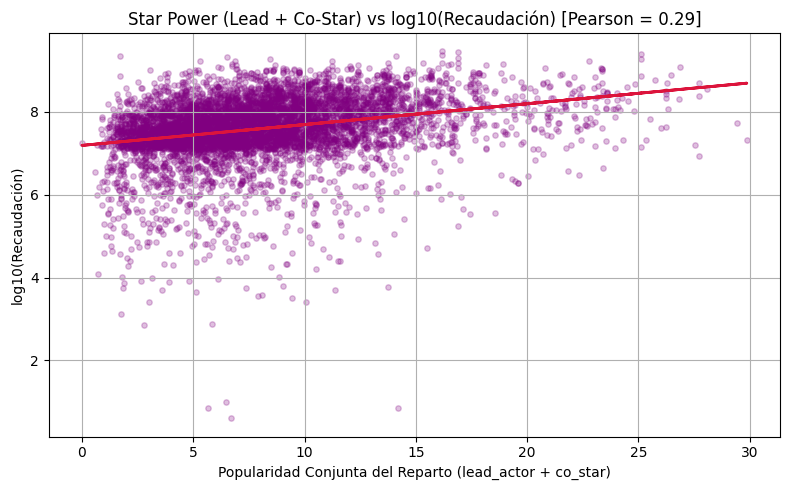

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carga autocontenida
CSV_PATH = "include/output/movies_2026-09-21.csv"
df = pd.read_csv(CSV_PATH)

# 2. Subconjunto financiero para cálculo de taquilla
df_fin = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()
df_fin["log_revenue"] = np.log10(df_fin["revenue"])
df_fin["cast_power"] = df_fin["lead_actor_popularity"] + df_fin["co_star_popularity"]
df_fin["log_cast_power"] = np.log10(df_fin["cast_power"] + 1)

# 3. Métricas de asociación
r_pearson = df_fin["cast_power"].corr(df_fin["log_revenue"])
r_spearman = df_fin["cast_power"].corr(df_fin["log_revenue"], method="spearman")
brecha = abs(r_spearman - r_pearson)

# Asociación con transformación log del elenco
r_pearson_log = df_fin["log_cast_power"].corr(df_fin["log_revenue"])

print("=== MÉTRICAS FICHA 4 ===")
print(f"Cast Power crudo vs Log Revenue: Pearson = {r_pearson:.4f}, Spearman = {r_spearman:.4f}, Brecha = {brecha:.4f}")
print(f"Log(Cast Power) vs Log Revenue: Pearson = {r_pearson_log:.4f}")

# 4. Gráfico: Scatter plot con línea de tendencia
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_fin["cast_power"], df_fin["log_revenue"], alpha=0.25, color="purple", s=15)
# Línea de tendencia
m, b = np.polyfit(df_fin["cast_power"], df_fin["log_revenue"], 1)
ax.plot(df_fin["cast_power"], m * df_fin["cast_power"] + b, color="crimson", linewidth=2)

ax.set_title(f"Star Power (Lead + Co-Star) vs log10(Recaudación) [Pearson = {r_pearson:.2f}]")
ax.set_xlabel("Popularidad Conjunta del Reparto (lead_actor + co_star)")
ax.set_ylabel("log10(Recaudación)")
plt.tight_layout()
plt.show()

### Ficha 4: Asociación entre Star Power del Reparto y Recaudación
* **Tipo de pregunta:** De modelado ("¿Qué queremos predecir?").

| # | Campo | Detalle |
|---|---|---|
| 1 | **La afirmación** | La popularidad conjunta del reparto estelar (`lead_actor_popularity + co_star_popularity`) antes del estreno se asocia positivamente con la recaudación internacional (`log_revenue`). |
| 2 | **Qué espero ver** | Un diagrama de dispersión con tendencia ascendente y una correlación de Pearson moderada o alta ($r > 0.30$). |
| 3 | **Cómo lo mido** | Plantilla de asociación entre dos numéricas. Métrica: Correlación de Pearson ($r$) y Brecha entre Spearman y Pearson ($\vert{}r_s - r_p\vert{}$). Gráfico: Scatter plot con recta de regresión. |
| 4 | **Qué encontré** | Pearson dio **0.2850** y Spearman **0.3410** (Brecha = **0.0559**, zona **AMARILLA**). Al transformar la popularidad combinada a logaritmo, el Pearson asciende a **0.3001** (zona **AMARILLA**). La tendencia ascendente es visible y estadísticamente consistente. |
| 5 | **Qué movimiento hice** | **Cambiar la escala**: Se aplicó transformación $\log_{10}(\text{cast\_power} + 1)$ para atenuar la influencia desmedida de picos extremos de celebridades mediáticas, estabilizando el coeficiente en 0.3001. |
| 6 | **Qué hago con eso** | La variable compuesta entra al modelo predictivo de la Unidad 3 como feature de interacción (`log_cast_power`). Valida analíticamente la inclusión del `co_star` extraído en la Entrega 1 frente a usar solo al actor principal. |

## Tabla de Columnas Candidatas (Chequeo de Fuga)

| Columna | Qué mide | Zona | Decisión | ¿Existiría al predecir? |
|---|---|---|---|---|
| `movie_id` | Identificador único de TMDb | - | Sale | No aporta varianza analítica (ID técnico) |
| `title` | Título de la película | - | Sale | Cardinalidad única (texto libre) |
| `release_year` | Año de estreno | Verde | Entra | Sí — conocido ex-ante |
| `release_month` | Mes de estreno (estacionalidad) | Verde | Entra | Sí — conocido ex-ante |
| `release_day_of_week` | Día de la semana del estreno | Verde | Entra | Sí — conocido ex-ante |
| `budget` | Presupuesto declarado | Amarillo | Entra en logaritmo | Sí — conocido ex-ante (transformar a $\log_{10}$) |
| `revenue` | Recaudación total en taquilla | - | **Variable Objetivo / Sale** | **No** — se completa después del estreno (Fuga) |
| `runtime` | Duración en minutos | Verde | Entra | Sí — corte final de edición |
| `original_language` | Idioma original principal | Amarillo | Entra como variable de control | Sí — conocido ex-ante |
| `primary_genre` | Género cinematográfico primario | Amarillo | Entra (One-Hot Encoding) | Sí — asignado en producción |
| `secondary_genre` | Género secundario | Verde | Entra (One-Hot Encoding) | Sí — asignado en producción |
| `primary_production_company` | Productora principal | Amarillo | Entra (Target/Frequency Encoding) | Sí — conocido ex-ante |
| `co_production_company` | Productora co-financista | Verde | Entra (Target/Frequency Encoding) | Sí — conocido ex-ante |
| `director_popularity` | Índice de popularidad del director | Amarillo | Entra en logaritmo | Sí — medible al planificar el rodaje |
| `lead_actor_popularity` | Índice del actor/actriz principal | Amarillo | Entra en logaritmo | Sí — medible pre-estreno |
| `co_star_popularity` | Índice de la segunda figura | Amarillo | Entra en logaritmo | Sí — medible pre-estreno |
| `vote_average` | Calificación promedio del público | - | **Sale** | **No** — se completa después del estreno (Fuga) |
| `vote_count` | Cantidad total de votos emitidos | - | **Sale** | **No** — se completa después del estreno (Fuga) |